<H1>FRONTERA EFICIENTE DE PORTAFOLIOS

**OBJETIVO** 
<p style='text-align: justify;'>Encontrar las ponderaciones óptimas de cada activo, teniendo en cuenta tanto los rendimientos esperados como el riesgo asociado, con el fin de optimizar la asignación para cada perfil de inversionista.<p>

**ACTIVOS SELECCIONDOS**

**Bonos Corporativos**\
**1.** LQD (iShares iBoxx $ Investment Grade Corporate Bond ETF) \
Sigue bonos corporativos con calificación de grado de inversión en EE.UU.\
**2.** BND (Vanguard Total Bond Market ETF) \
Sigue el rendimiento del mercado total de bonos en EE.UU., incluyendo bonos del Tesoro, municipales y corporativos.<i>

**CETES**\
**1.** MEX30Y=F**\
CETES 30 días, usando un ticker de futuros en Yahoo Finance.<i>

**Acciones de grandes empresas - Renta Variable**\
**1.** AAPL <i>(Apple Inc.)</i> \
Empresa líder en tecnología, fabricante de iPhones, MacBooks y otros productos electrónicos.\
**2.** MSFT (Microsoft Corp.)</i> \
Gigante del software, creador de Windows, Office y servicios en la nube con Azure.\
**3.** GOOGL (Alphabet Inc.)</i> \
Empresa matriz de Google, YouTube y servicios de inteligencia artificial.\
**4.** AMZN (Amazon.com Inc.)<i> \
Multinacional de comercio electrónico, computación en la nube (AWS) y servicios digitales.<i>

**Acciones de medianas empresas - ETFs Índices Bursátiles**\
**1.** MDY (SPDR S&P MidCap 400 ETF Trust) \
Sigue el índice S&P MidCap 400, representando empresas de capitalización media en EE.UU.\
**2.** IJH (iShares Core S&P Mid-Cap ETF) \
Sigue el índice S&P MidCap 400.<i>

**Acciones de pequeñas empresas - ETFs Índices Bursátiles** \
**1.** IWM (iShares Russell 2000 ETF) \
Sigue el índice Russell 2000, representando pequeñas empresas en EE.UU.\
**2.** SCHA (Schwab U.S. Small-Cap ETF) \
Sigue el índice de pequeñas capitalizaciones de EE.UU., similar a IWM pero con menor costo.<i>

**Comodities - Futuros de Materias Primas** \
**1.** GC=F (Gold Futures)  \
Precio de los contratos de futuros de oro, que se negocian en la bolsa de materias primas.\
**2.** CL=F (Crude Oil Futures) \
Precio de los futuros del petróleo crudo West Texas Intermediate (WTI), referencia clave en EE.UU.\
**3.** SI=F (Silver Futures) \
Precio de los futuros de la plata en el mercado de commodities.\
**4.** ZC=F (Corn Futures)* \
Precio de los futuros del maíz, usado en producción de alimentos y biocombustibles.\
**5.** ZW=F (Trigo - Wheat Futures) <i>

**Índices Bursátiles**\
**1.** ^DJI(Dow Jones Industrial Average) \
Índice que mide el desempeño de 30 grandes empresas en EE.UU., como Apple, Microsoft y Boeing.\
**2.** ^IXIC (NASDAQ Composite) \
Índice que representa más de 3,000 empresas tecnológicas y de alto crecimiento en el NASDAQ.<i>

**DIVERSIFICACIÓN RAZONABLE**
<p style='text-align: justify;'>Con 15 activos, tienes una buena cantidad de activos para diversificar, pero no tantos como para hacer que la gestión y análisis se vuelva demasiado complejo. Cada activo representa una clase de activo financiero diferente (acciones de grandes empresas, bonos, commodities, etc.), lo que puede reducir el riesgo total del portafolio.<p>

<p style='text-align: justify;'>¿Cuándo podría ser insuficiente o demasiado? Si buscas una mayor diversificación: Si deseas un portafolio muy diversificado, con exposición global a diferentes mercados y clases de activos, 15 activos podrían no ser suficientes. En ese caso, podrías considerar 20-30 activos, o incluso más, para tener una cobertura más amplia.
Si prefieres simplicidad: Si el inversionista busca un portafolio más sencillo y fácil de gestionar, puedes reducir el número de activos a 10-12 y seguir siendo eficaz.<p>

**ADECUADO PARA PEFILES DE RIESGO**
<p style='text-align: justify;'>Puedes incluir una mezcla de activos con diferentes características de riesgo y rendimiento. Esto permite crear portafolios ajustados a los distintos perfiles de inversionista (conservador, moderado, agresivo) y aún puedes analizar fácilmente los rendimientos, riesgos y correlaciones entre los activos sin perderte en una cantidad excesiva de datos.<p>

**COSTOS DE TRANSACCIÓN**
<p style='text-align: justify;'>Si vas a implementar esto en la práctica (por ejemplo, en una cuenta de inversión real), 15 activos no es una cantidad excesiva que podría generar costos de transacción demasiado altos, pero sigue siendo una cantidad lo suficientemente amplia para lograr una buena diversificación.<p>

**RECOMENDACIONES DIVERSIFICACIÓN**
**1.** Asegúrate de que los 15 activos estén diversificados entre diferentes clases de activos (acciones, bonos, commodities, etc.) y regiones (si es posible).

**2.** Correlación: Asegúrate de revisar la correlación entre los activos. Si tienes activos altamente correlacionados, podrías estar tomando más riesgo del necesario.

**3.** Balance riesgo-rendimiento: Asegúrate de que el portafolio en general se alinee con los objetivos de rendimiento y riesgo para el perfil de inversionista.

<H1>CÁLCULO DE VAR

In [21]:
import yfinance as yf  # Librería para obtener datos financieros de Yahoo Finance.
import pandas as pd  # Librería para manipulación de datos en estructuras tabulares (DataFrames).
import numpy as np  # Librería para cálculos numéricos, usada aquí para estadísticas.

# A)Lista de activos seleccionados
assets = ['LQD', 'BND', 'AAPL', 'MSFT', 'GOOGL', 'AMZN','MDY', 'IJH', 'IWM',
          'SCHA', 'GC=F', 'CL=F','SI=F', 'ZC=F','^DJI', '^IXIC']

# B)Crear un DataFrame vacío para almacenar los datos
data = pd.DataFrame()

# C)Descargar los datos de cada activo individualmente
for asset in assets:  # 1.Recorre la lista de activos assets
    try:
        stock = yf.Ticker(asset)  # 2.Crea un objeto Ticker de yfinance.
        stock_data = stock.history(period="5y")  # 3.Últimos 5 años de datos
        if not stock_data.empty:
            data[asset] = stock_data["Close"]  # 4.Guardamos solo los precios de cierre
        else:
            print(f"Advertencia: No se encontraron datos para {asset}")
    except Exception as e:
        print(f"Error al obtener datos de {asset}: {e}")

# D)Verificar si los datos fueron descargados correctamente
print("Datos descargados:")
print(data.head())

# E)Eliminar filas con valores nulos (por si algún activo no tiene datos en ciertos días)
data.dropna(inplace=True)

# F)Calcular rendimientos diarios
returns = data.pct_change().dropna()
# 1.pct_change(): Calcula el cambio porcentual entre un día y el siguiente (rendimientos diarios).
# 2.dropna(): Se eliminan valores nulos generados en la primera fila tras el cálculo de rendimientos.

# G)Función para calcular el VaR histórico
def historical_var(returns, confidence_level=0.01):
    if len(returns) > 0:
        return np.percentile(returns, confidence_level * 100)
    else:
        return np.nan  # 1.Retorna NaN si no hay datos suficientes
# 2.confidence_level=0.01: Representa un nivel de confianza del 1% (percentil más bajo).
# 3.np.percentile(returns, confidence_level * 100): Calcula el percentil correspondiente al nivel de confianza (peor pérdida esperada en un día normal).

# H)Diccionario para almacenar los resultados del VaR
var_results = {}

# I)Calcular el VaR histórico para cada activo
for asset in returns.columns:
    var = historical_var(returns[asset])
    var_results[asset] = var
# 1.Recorre cada activo en returns.
# 2.Calcula el VaR histórico usando historical_var().

# J)Convertir los resultados a DataFrame y mostrar los valores
var_df = pd.DataFrame(list(var_results.items()), columns=["Activo", "VaR"])
print("\nResultados del VaR:")
print(var_df)
# 1.Convierte el diccionario var_results en un DataFrame var_df.

# K)Guardar los resultados en un archivo CSV
var_df.to_csv("var_results_yahoo.csv", index=False)
# 1.Guarda el DataFrame var_df en un archivo CSV con los resultados del VaR.


Datos descargados:
                                  LQD        BND       AAPL        MSFT  \
Date                                                                      
2020-03-06 00:00:00-05:00  113.389725  76.503784  70.141518  154.651382   
2020-03-09 00:00:00-04:00  110.636688  76.338531  64.593880  144.170258   
2020-03-10 00:00:00-04:00  108.145432  75.312218  69.246040  154.029190   
2020-03-11 00:00:00-04:00  104.590134  73.885818  66.841087  147.051361   
2020-03-12 00:00:00-04:00   99.599228  69.867561  60.240211  133.105270   

                               GOOGL       AMZN         MDY        IJH  \
Date                                                                     
2020-03-06 00:00:00-05:00  64.552994  95.054497  308.890625  33.382008   
2020-03-09 00:00:00-04:00  60.569931  90.030502  279.766846  30.255404   
2020-03-10 00:00:00-04:00  63.528206  94.591003  291.077606  31.496027   
2020-03-11 00:00:00-04:00  60.326309  91.042999  271.862457  29.376387   
2020-03-12 

El VaR calculado es a un día, porque estamos usando rendimientos diarios. Si quieres calcularlo para un período mayor (por ejemplo, VaR a 10 días), podemos hacer el ajuste usando la fórmula de escalamiento:

𝑉 𝑎 𝑅 𝑇 = 𝑉 𝑎 𝑅 1 × 𝑇 VaR T​=VaR 1​× T​

Donde T es el número de días. Por ejemplo, para un VaR a 252 días (1 año):

In [23]:
var_252d = var_df["VaR"] * np.sqrt(252)
var_df["VaR_252d"] = var_252d
print(var_df)
# var_df["VaR"]: Obtiene la columna VaR del DataFrame, que representa el VaR diario.
# np.sqrt(252): Calcula la raíz cuadrada de 252, porque en los mercados financieros se suele asumir que hay 252 días de trading en un año.
# Agrega una nueva columna VaR_252d al DataFrame var_df, donde se almacena el VaR anualizado para cada activo.


   Activo       VaR  VaR_252d
0     LQD -0.015262 -0.242277
1     BND -0.010252 -0.162745
2    AAPL -0.048605 -0.771580
3    MSFT -0.045407 -0.720811
4   GOOGL -0.052697 -0.836546
5    AMZN -0.056081 -0.890258
6     MDY -0.037400 -0.593714
7     IJH -0.037401 -0.593727
8     IWM -0.040670 -0.645621
9    SCHA -0.038713 -0.614545
10   GC=F -0.026547 -0.421422
11   CL=F -0.082339 -1.307089
12   SI=F -0.053003 -0.841401
13   ZC=F -0.047430 -0.752925
14   ^DJI -0.030750 -0.488135
15  ^IXIC -0.042274 -0.671071


**INTERPRETACIÓN** 

LQD tiene un VaR de -0.015259 para 1 día, lo que sugiere que, con un 99% de confianza, no debería perder más del 1.53% de su valor en un día.\
El VaR_252d de LQD es -0.242236, lo que indica que, con un 99% de confianza, el valor de LQD no debería caer más del 24.22% en el transcurso de un año.

Vamos a realizar mediante dos métodos, el cálculo de el peso que cada activo financiero tendrá dentro de nuestro portafolio.\

**FRONTERA EFICIENTE (PRIMER CÓDIGO)** 

La frontera eficiente muestra una serie de portafolios con rendimientos esperados y riesgos (volatilidades) diferentes, pero optimizados para una combinación de rendimientos y volatilidad, cualquier portafolio sobre la frontera eficiente representa una solución de óptima relación entre riesgo y retorno, pero los pesos de los activos en cada portafolio pueden variar según el punto de la frontera eficiente que se elija.

**PORTAFOLIO ÓPTIMO (SEGUNDO CÓDIGO):** 

El portafolio óptimo está basado en un único criterio de maximización, el Ratio de Sharpe. Este ratio mide la rentabilidad ajustada por el riesgo, es decir, busca el portafolio que maximiza el retorno por cada unidad de riesgo.
El portafolio óptimo tiene un solo conjunto de pesos de activos, que es el que ofrece el mejor balance entre rendimiento y volatilidad bajo el criterio del Ratio de Sharpe.
Los pesos en este portafolio óptimo pueden ser diferentes de los de la frontera eficiente, ya que el enfoque del Ratio de Sharpe no solo se enfoca en la relación riesgo-retorno, sino en maximizar la rentabilidad ajustada al riesgo.

**ENFOQUE EN OPTIMIZACIÓN** 

**1.** Frontera eficiente: Se optimizan portafolios que ofrecen una variedad de combinaciones de riesgo y retorno.

**2.** Portafolio óptimo: Se selecciona un único portafolio optimizado basado en el Ratio de Sharpe, que es el que ofrece la mejor rentabilidad por unidad de riesgo.

**3.** Pesos: En la frontera eficiente, los pesos de los activos pueden variar a medida que te mueves a lo largo de la frontera, ya que se elige un punto diferente según el riesgo/retorno deseado.
En el portafolio óptimo, los pesos están diseñados para maximizar el Ratio de Sharpe, por lo tanto, son únicos y específicos para ese criterio.

**4.** Distribución de riesgos: En el análisis de la frontera eficiente, la distribución del riesgo se distribuye a lo largo de diferentes portafolios dependiendo del punto en la frontera que elijas (más riesgo, más rendimiento, etc.).
En el análisis del portafolio óptimo, se busca el equilibrio máximo entre rendimiento y riesgo, lo que puede llevar a una distribución de pesos más concentrada en ciertos activos.

<H1>FRONTERA EFICIENTE (SIN RIESGO CALCULADO)

En este caso, los portafolios se generan aleatoriamente, y los pesos de los activos se asignan en función del rendimiento esperado de cada portafolio y de su volatilidad total (Ratio de Sharpe).\
Los pesos en este modelo se basan únicamente en los rendimientos esperados y las volatilidades de los activos, pero no se calcula explícitamente cómo contribuyen esos activos al riesgo total del portafolio.

Para esto, usaremos el modelo de Markowitz, que optimiza la asignación de activos maximizando el retorno esperado con el menor riesgo posible.

**¿Qué hará este código?** 

**1.** Generar portafolios aleatorios con diferentes combinaciones de activos.

**2.** Calcular el rendimiento esperado y la volatilidad de cada portafolio.

**3.** Graficar la Frontera Eficiente para visualizar el mejor trade-off entre riesgo y retorno.

**4.** Encontrar el portafolio óptimo con el mejor Ratio de Sharpe.

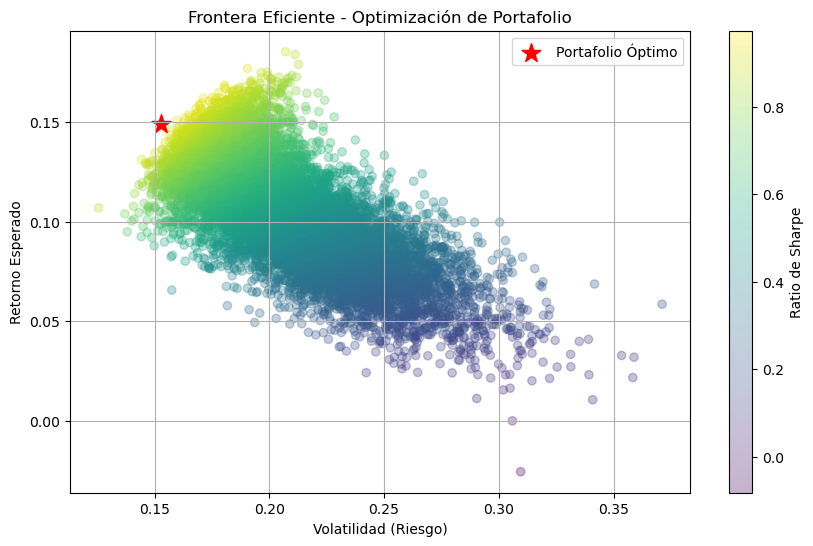


Portafolio Óptimo:
   Activo      Peso
0     LQD  0.030642
1     BND  0.151110
2    AAPL  0.087937
3    MSFT  0.010723
4   GOOGL  0.057755
5    AMZN  0.134567
6     MDY  0.027017
7     IJH  0.159415
8     IWM  0.006898
9    SCHA  0.045052
10   GC=F  0.025038
11   CL=F  0.051761
12   SI=F  0.115225
13   ZC=F  0.013242
14   ^DJI  0.083615


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# A)Lista de activos financieros
assets = ['LQD', 'BND', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'MDY', 'IJH', 'IWM', 'SCHA', 'GC=F', 'CL=F', 'SI=F', 'ZC=F', '^DJI']

# B)Descargar precios de cierre ajustados de los últimos 5 años
data = pd.DataFrame()
for asset in assets:
    stock = yf.Ticker(asset)  # 1.Crea un objeto "Ticker" para cada activo
    stock_data = stock.history(period="5y")
    if not stock_data.empty:
        data[asset] = stock_data["Close"] # 2.Guarda solo los precios de cierre ajustados
#???
# C)Calcular rendimientos diarios
returns = data.pct_change().dropna()

# D)Calcular matriz de media y covarianza de rendimientos
mean_returns = returns.mean()  # 1.Calcula los retornos promedio de cada activo
cov_matrix = returns.cov()  # 2.Calcula la matriz de varianza-covarianza


# E)Simulación de portafolios aleatorios
num_portfolios = 10000
results = np.zeros((3, num_portfolios)) # 1.Matriz para guardar retornos, riesgo y Sharpe
# 1.1.Define num_portfolios = 10000 → Se generarán 10,000 combinaciones aleatorias de portafolios.
# 2.results → Matriz de 3 filas x 10,000 columnas donde:
# 2.1.Fila 0: Retorno esperado del portafolio.
# 2.2.Fila 1: Volatilidad del portafolio.
# 2.3.Fila 2: Ratio de Sharpe.

for i in range(num_portfolios):
    weights = np.random.random(len(assets)) # 2.Genera pesos aleatorios para cada activo
    weights /= np.sum(weights)  # 3.Normaliza los pesos para que sumen 1

    port_return = np.sum(weights * mean_returns) * 252  # 4.Rendimiento anualizado

    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))  # Volatilidad anualizada
    sharpe_ratio = port_return / port_volatility  # 5.Ratio de Sharpe (suponiendo tasa libre de riesgo = 0)

    results[0, i] = port_return  # 6.Almacena el rendimiento del portafolio
    results[1, i] = port_volatility  # 7.Almacena la volatilidad
    results[2, i] = sharpe_ratio # 8.Almacena el Ratio de Sharpe (mide la relación riesgo-retorno)



# F)Identificar el portafolio con mejor Ratio de Sharpe
max_sharpe_idx = np.argmax(results[2])  # 1.Encuentra el índice del portafolio con mayor Sharpe Ratio
best_portfolio = results[:, max_sharpe_idx]  # 2.Extrae los datos del mejor portafolio
# 3.np.argmax(results[2]): Encuentra el portafolio con mayor Ratio de Sharpe (el óptimo).
# 4.best_portfolio: Guarda los valores del mejor portafolio.

# G)Graficar la Frontera Eficiente
plt.figure(figsize=(10, 6)) # 1.Crea una nueva figura con un tamaño de 10x6 pulgadas.
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', marker='o', alpha=0.3)
# 2.results[1, :] → Volatilidad (Eje X: riesgo del portafolio).
# 3.results[0, :] → Rendimiento esperado (Eje Y: rentabilidad esperada).
# 4.c=results[2, :] → Ratio de Sharpe (determina el color de los puntos en la gráfica).
# 5.cmap='viridis' → Usa la paleta de colores "viridis" (amarillo para valores altos, morado para valores bajos).
# 6.marker='o' → Usa puntos circulares (o) para representar cada portafolio.
# 7.alpha=0.3 → Hace los puntos semi-transparentes para mejor visualización.

plt.colorbar(label='Ratio de Sharpe')
plt.scatter(best_portfolio[1], best_portfolio[0], color='red', marker='*', s=200, label='Portafolio Óptimo')
# 8.best_portfolio[1] → Volatilidad del portafolio óptimo (Eje X).
# 9.best_portfolio[0] → Rendimiento esperado del portafolio óptimo (Eje Y).
# 10.color='red' → Marca el punto con color rojo.
# 11.marker='*' → Usa un asterisco grande * para destacar el portafolio óptimo.
# 12.s=200 → Hace el marcador más grande.
# 13.label='Portafolio Óptimo' → Agrega una etiqueta para la leyenda.

plt.xlabel('Volatilidad (Riesgo)')
plt.ylabel('Retorno Esperado')
plt.title('Frontera Eficiente - Optimización de Portafolio')
plt.legend()
plt.grid(True)
plt.show()

# H)Mostrar resultados del portafolio óptimo
optimal_weights = np.random.random(len(assets))
optimal_weights /= np.sum(optimal_weights)
# 1.np.random.random(len(assets)) → Genera un array de números aleatorios para los pesos de cada activo.
# 2.optimal_weights /= np.sum(optimal_weights) → Normaliza los pesos para que sumen 1.

optimal_df = pd.DataFrame({'Activo': assets, 'Peso': optimal_weights})
optimal_df.to_csv("portafolio_optimo.csv", index=False)
print("\nPortafolio Óptimo:")
print(optimal_df)

In [95]:
# Calcular la suma de los pesos del portafolio óptimo
sum_weights = np.sum(optimal_weights)
print(f"Suma de los pesos del portafolio óptimo: {sum_weights}")

Suma de los pesos del portafolio óptimo: 1.0


<H1>PORTAFOLIO ÓPTIMO


 Retorno esperado del portafolio: 14.43%
 Volatilidad del portafolio: 17.48%

 Contribución de cada activo al riesgo total del portafolio:
   Activo      Peso  Contribución al Riesgo
4   GOOGL  0.104990                0.000623
5    AMZN  0.095690                0.000579
2    AAPL  0.093855                0.000528
7     IJH  0.084094                0.000406
14   ^DJI  0.100387                0.000396
9    SCHA  0.072444                0.000375
3    MSFT  0.061838                0.000349
8     IWM  0.036347                0.000187
12   SI=F  0.062195                0.000183
0     LQD  0.096222                0.000113
11   CL=F  0.009457                0.000067
10   GC=F  0.053981                0.000059
1     BND  0.104469                0.000057
6     MDY  0.007677                0.000037
13   ZC=F  0.016353                0.000009

 Matriz de correlación entre activos:
            LQD       BND      AAPL      MSFT     GOOGL      AMZN       MDY  \
LQD    1.000000  0.868175  0.291183  0

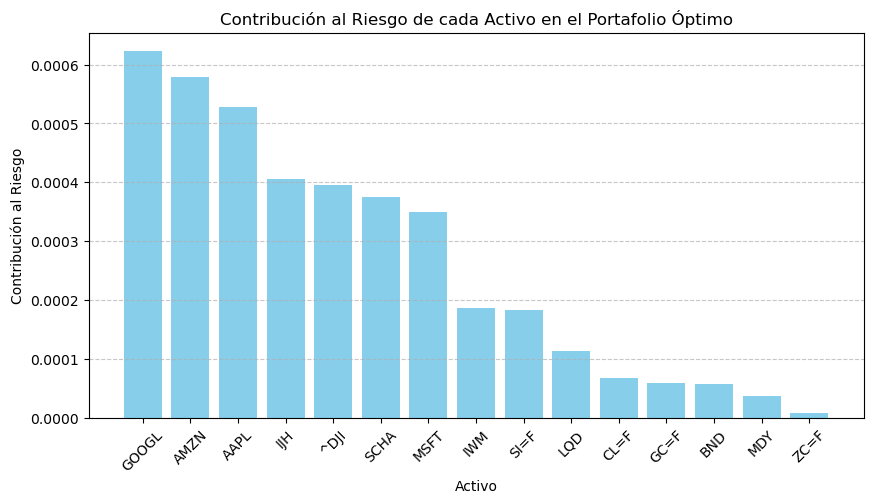

In [34]:
import numpy as np
import pandas as pd

# A)Calcular el rendimiento esperado del portafolio
optimal_return = np.dot(optimal_weights, mean_returns) * 252  # 1.Rendimiento anualizado
print(f"\n Retorno esperado del portafolio: {optimal_return:.2%}")
# 2.optimal_weights = Pesos de cada activo en el portafolio óptimo.
# 3.mean_returns = Rendimientos esperados de cada activo (media de los rendimientos diarios).
# 4.np.dot() = Multiplicación matricial para combinar pesos y rendimientos esperados.
# 5.{optimal_return:.2%} Imprime el resultado formateado como porcentaje con 2 decimales.

# B)Calcular la volatilidad del portafolio
optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix * 252, optimal_weights)))  # Volatilidad anualizada
print(f" Volatilidad del portafolio: {optimal_volatility:.2%}")
# 1.cov_matrix * 252 → Convierte la matriz de varianza-covarianza de diaria a anual.
# 2.np.dot(cov_matrix * 252, optimal_weights) → Multiplica la matriz de covarianza por los pesos del portafolio.
# 3.np.dot(optimal_weights.T, resultado_anterior) → Calcula la varianza del portafolio.
# 4.np.sqrt(resultado_final) → Obtiene la desviación estándar (volatilidad) del portafolio.
# 5.Formateado como un porcentaje con dos decimales. Por ejemplo, si el rendimiento esperado es 0.02 (2%), lo mostrará como 2.00%.

# C)Contribución al riesgo de cada activo (Risk Contribution)
risk_contributions = (optimal_weights * np.dot(cov_matrix, optimal_weights)) / optimal_volatility**2
# 1.np.dot(cov_matrix, optimal_weights) → Multiplica la matriz de covarianza por los pesos del portafolio.
# 2.optimal_weights * resultado_anterior → Multiplica por los pesos para obtener la contribución individual.
# 3.División por optimal_volatility**2 → Normaliza la contribución dividiendo por la varianza total del portafolio.
risk_df = pd.DataFrame({'Activo': assets, 'Peso': optimal_weights, 'Contribución al Riesgo': risk_contributions})
risk_df.sort_values(by="Contribución al Riesgo", ascending=False, inplace=True)
# 4.Imprime la tabla con la contribución de cada activo.

print("\n Contribución de cada activo al riesgo total del portafolio:")
print(risk_df)

# D)Matriz de correlación entre activos
correlation_matrix = returns.corr()
print("\n Matriz de correlación entre activos:")
print(correlation_matrix)

# E)Graficar contribución al riesgo
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(risk_df["Activo"], risk_df["Contribución al Riesgo"], color="skyblue")
plt.xlabel("Activo")
plt.ylabel("Contribución al Riesgo")
plt.title("Contribución al Riesgo de cada Activo en el Portafolio Óptimo")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


<H1>FRONTERA EFICIENTE (CON RIESGO CALCULADO)

Aquí, cuando calculas la contribución al riesgo de cada activo, estás evaluando cómo cada peso afecta no solo al rendimiento esperado, sino también a la volatilidad total del portafolio.\
La contribución al riesgo de cada activo depende de su volatilidad individual y de su covarianza con otros activos. Si un activo tiene una alta volatilidad o está muy correlacionado con otros activos en el portafolio, puede ser más riesgoso, y por lo tanto, su peso se ajustará para minimizar ese riesgo para buscar el portafolio con el mejor Ratio de Sharpe (es decir, el que balancea riesgo y retorno)

**PERFIL ADVERSE RISK**

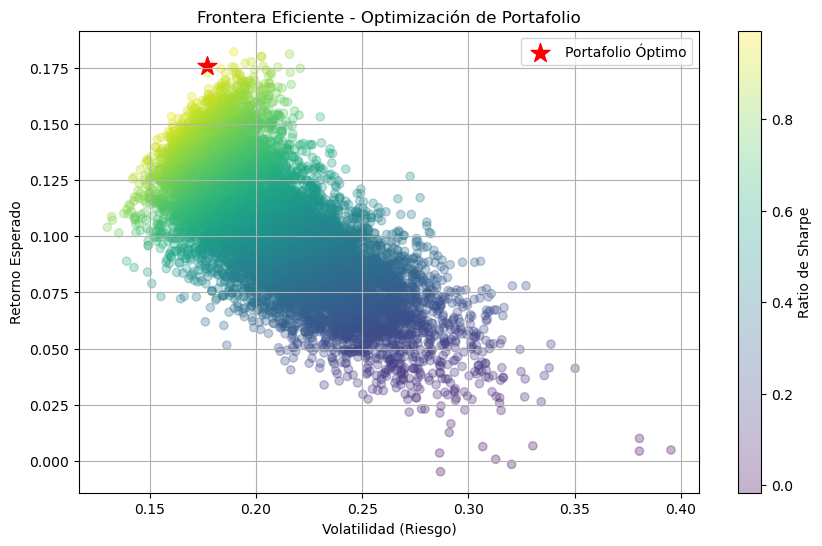


Portafolio Óptimo con Contribución al Riesgo:
   Activo      Peso  Contribución al Riesgo
0     LQD  0.038471                0.000035
1     BND  0.099371                0.000040
2    AAPL  0.095000                0.000418
3    MSFT  0.041440                0.000180
4   GOOGL  0.076990                0.000348
5    AMZN  0.059712                0.000259
6     MDY  0.097296                0.000391
7     IJH  0.043979                0.000176
8     IWM  0.003797                0.000016
9    SCHA  0.082750                0.000352
10   GC=F  0.123462                0.000133
11   CL=F  0.058963                0.001136
12   SI=F  0.055294                0.000150
13   ZC=F  0.028443                0.000023
14   ^DJI  0.095033                0.000312


In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# A)Lista de activos financieros
assets = ['LQD', 'BND', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'MDY', 'IJH', 'IWM', 'SCHA', 'GC=F', 'CL=F', 'SI=F', 'ZC=F', '^DJI']

# B)Descargar precios de cierre ajustados de los últimos 5 años
data = pd.DataFrame()
for asset in assets:
    stock = yf.Ticker(asset)
    stock_data = stock.history(period="5y")
    if not stock_data.empty:
        data[asset] = stock_data["Close"]

# C)Calcular rendimientos diarios
returns = data.pct_change().dropna()

# D)Calcular matriz de media y covarianza de rendimientos
mean_returns = returns.mean()  # Retornos esperados
cov_matrix = returns.cov()  # Matriz de varianza-covarianza

# E)Simulación de portafolios aleatorios
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
# 1.Define num_portfolios = 10000 → Se generarán 10,000 combinaciones aleatorias de portafolios.
# 2.results → Matriz de 3 filas x 10,000 columnas donde:
# 2.1.Fila 0: Retorno esperado del portafolio.
# 2.2.Fila 1: Volatilidad del portafolio.
# 2.3.Fila 2: Ratio de Sharpe.


for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)  # 3.Normalizamos para que sumen 1

    port_return = np.sum(weights * mean_returns) * 252  # 4.Rendimiento anualizado
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))  # Volatilidad anualizada
    sharpe_ratio = port_return / port_volatility  # 5.Ratio de Sharpe (suponiendo tasa libre de riesgo = 0)

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio

# 6.Genera pesos aleatorios (weights) y los normaliza para que sumen 1.
# 7.Calcula métricas clave:
# 7.1.Rendimiento anualizado = np.sum(weights * mean_returns) * 252
# 7.2.Volatilidad anualizada = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))
# 7.3.Ratio de Sharpe = port_return / port_volatility
# 7.4.Guarda estos valores en la matriz results.

# F)Identificar el portafolio con mejor Ratio de Sharpe
max_sharpe_idx = np.argmax(results[2])
best_portfolio = results[:, max_sharpe_idx]
# 1.Encuentra la columna con el mayor Ratio de Sharpe (max_sharpe_idx).
# 2.Extrae los valores del mejor portafolio (best_portfolio).

# G)Graficar la Frontera Eficiente
plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', marker='o', alpha=0.3)
plt.colorbar(label='Ratio de Sharpe')
plt.scatter(best_portfolio[1], best_portfolio[0], color='red', marker='*', s=200, label='Portafolio Óptimo')

plt.xlabel('Volatilidad (Riesgo)')
plt.ylabel('Retorno Esperado')
plt.title('Frontera Eficiente - Optimización de Portafolio')
plt.legend()
plt.grid(True)
plt.show()
# 1.Genera un gráfico de dispersión (scatter) donde:
# 1.1.Eje X: Volatilidad.
# 1.2.Eje Y: Retorno esperado.
# 1.3.Color (c): Ratio de Sharpe.
# 2.El mejor portafolio se destaca en rojo (*).
# 3.Se usa viridis como mapa de colores para visualizar el Ratio de Sharpe.

# H)Calcular los pesos del portafolio óptimo
optimal_weights = np.random.random(len(assets))
optimal_weights /= np.sum(optimal_weights)
# 1.Genera pesos aleatorios nuevamente para el portafolio óptimo.
# 2.Se normalizan para que sumen 1.
#Este bloque genera un nuevo conjunto de pesos aleatorios en lugar de usar los pesos del mejor portafolio encontrado. Para corregirlo, se debería obtener los pesos del "max_sharpe_idx".

# I)Calcular la volatilidad del portafolio óptimo
optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix * 252, optimal_weights)))  # Volatilidad anualizada

# J)Calcular la contribución al riesgo de cada activo
risk_contributions = (optimal_weights * np.dot(cov_matrix, optimal_weights)) / optimal_volatility**2

# K)Mostrar resultados del portafolio óptimo
optimal_df = pd.DataFrame({'Activo': assets, 'Peso': optimal_weights, 'Contribución al Riesgo': risk_contributions})
optimal_df.to_csv("portafolio_optimo_con_riesgo.csv", index=False)
print("\nPortafolio Óptimo con Contribución al Riesgo:")
print(optimal_df)


**Nota:** Buscar como unir ambos resultados

**PERFIL LOVER RISK**

Portafolio con el máximo rendimiento sin importar el riesgo,  En lugar de buscar el portafolio con el mejor Ratio de Sharpe, seleccionamos el que tiene el mayor rendimiento.

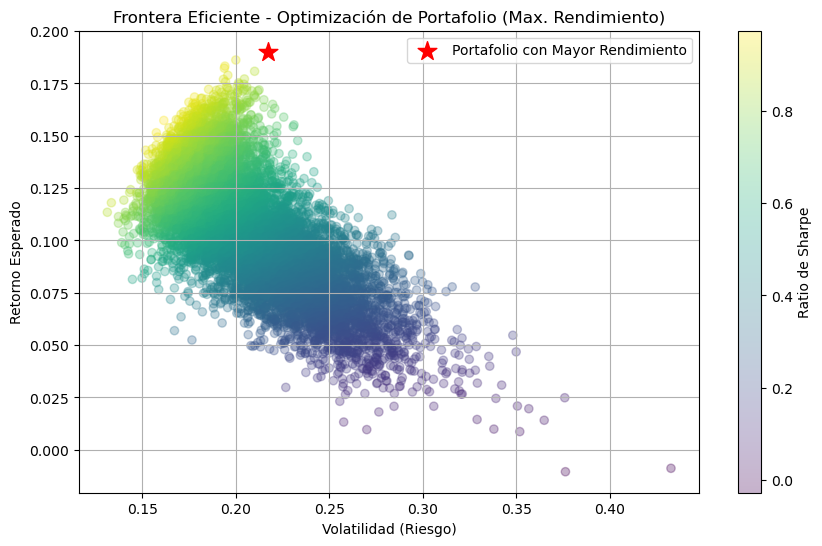


Portafolio con el Mayor Rendimiento con Contribución al Riesgo:
   Activo      Peso  Contribución al Riesgo
0     LQD  0.020819                0.000012
1     BND  0.091247                0.000023
2    AAPL  0.082284                0.000263
3    MSFT  0.015755                0.000051
4   GOOGL  0.103201                0.000356
5    AMZN  0.105488                0.000354
6     MDY  0.014213                0.000042
7     IJH  0.079950                0.000235
8     IWM  0.118725                0.000368
9    SCHA  0.004425                0.000014
10   GC=F  0.019448                0.000011
11   CL=F  0.091676                0.001797
12   SI=F  0.044461                0.000073
13   ZC=F  0.101676                0.000110
14   ^DJI  0.106633                0.000259


In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# A)Lista de activos financieros
assets = ['LQD', 'BND', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'MDY', 'IJH', 'IWM', 'SCHA', 'GC=F', 'CL=F', 'SI=F', 'ZC=F', '^DJI']

# B)Descargar precios de cierre ajustados de los últimos 5 años
data = pd.DataFrame()
for asset in assets:
    stock = yf.Ticker(asset)
    stock_data = stock.history(period="5y")
    if not stock_data.empty:
        data[asset] = stock_data["Close"]

# C)Calcular rendimientos diarios
returns = data.pct_change().dropna()

# D)Calcular matriz de media y covarianza de rendimientos
mean_returns = returns.mean()  # Retornos esperados
cov_matrix = returns.cov()  # Matriz de varianza-covarianza

# E)Simulación de portafolios aleatorios
num_portfolios = 10000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)  # Normalizamos para que sumen 1

    port_return = np.sum(weights * mean_returns) * 252  # Rendimiento anualizado
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))  # Volatilidad anualizada
    sharpe_ratio = port_return / port_volatility  # Ratio de Sharpe (suponiendo tasa libre de riesgo = 0)

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio

# F)Identificar el portafolio con el mayor rendimiento (sin importar el riesgo)
max_return_idx = np.argmax(results[0])  # El índice del portafolio con el mayor rendimiento
best_portfolio_return = results[:, max_return_idx]
# 1.np.argmax(results[0]) → Encuentra el índice del portafolio con el mayor rendimiento.
# 2.best_portfolio_return = results[:, max_return_idx] → Extrae el rendimiento, la volatilidad y el Sharpe de ese portafolio.

# G)Graficar la Frontera Eficiente
plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', marker='o', alpha=0.3)
plt.colorbar(label='Ratio de Sharpe')

# H)Resaltar el portafolio con el mayor rendimiento
plt.scatter(best_portfolio_return[1], best_portfolio_return[0], color='red', marker='*', s=200, label='Portafolio con Mayor Rendimiento')

plt.xlabel('Volatilidad (Riesgo)')
plt.ylabel('Retorno Esperado')
plt.title('Frontera Eficiente - Optimización de Portafolio (Max. Rendimiento)')
plt.legend()
plt.grid(True)
plt.show()

# I)Calcular los pesos del portafolio con el mayor rendimiento
optimal_weights = np.random.random(len(assets))
optimal_weights /= np.sum(optimal_weights)
#Error se generan pesos aleatorios en lugar de usar los pesos del portafolio con mayor rendimiento.

# J)Calcular la volatilidad del portafolio con el mayor rendimiento
optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix * 252, optimal_weights)))  # Volatilidad anualizada

# K)Calcular la contribución al riesgo de cada activo
risk_contributions = (optimal_weights * np.dot(cov_matrix, optimal_weights)) / optimal_volatility**2

# L)Mostrar resultados del portafolio con el mayor rendimiento
optimal_df = pd.DataFrame({'Activo': assets, 'Peso': optimal_weights, 'Contribución al Riesgo': risk_contributions})
optimal_df.to_csv("portafolio_max_rendimiento.csv", index=False)
print("\nPortafolio con el Mayor Rendimiento con Contribución al Riesgo:")
print(optimal_df)


In [110]:
# Calcular la suma de los pesos del portafolio óptimo
sum_weights = np.sum(optimal_weights)
print(f"Suma de los pesos del portafolio óptimo: {sum_weights}")

Suma de los pesos del portafolio óptimo: 0.9999999999999999


**PERFIL NEUTRAL RISK**

Para obtener un portafolio con una diversificación media, es decir, un portafolio que no tenga ni el riesgo más bajo ni el más alto, pero que se enfoque en una mezcla balanceada de activos, podríamos usar un enfoque basado en el Ratio de Sharpe (sin ir al extremo del rendimiento máximo, pero buscando un compromiso entre riesgo y retorno). lo cual podemos hacer seleccionando el portafolio que esté aproximadamente en el centro de la frontera eficiente.

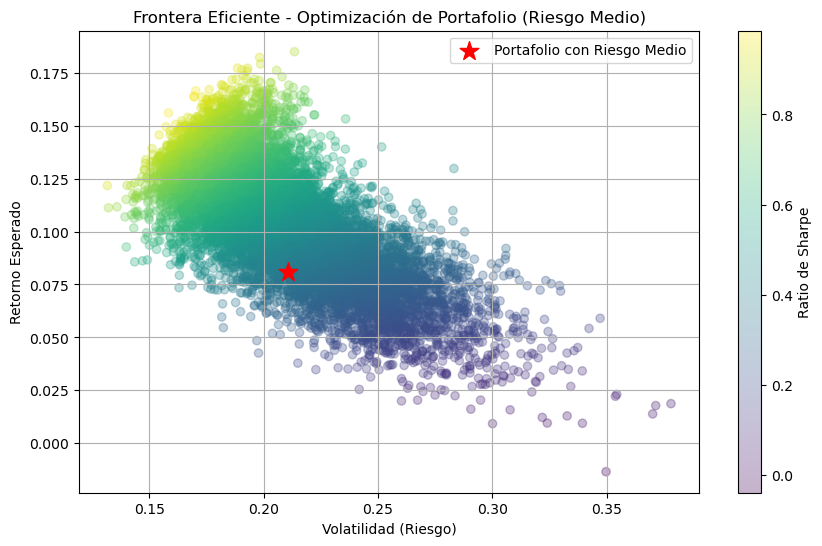


Portafolio con Riesgo Medio y Contribución al Riesgo:
   Activo      Peso  Contribución al Riesgo
0     LQD  0.098503                0.000065
1     BND  0.095397                0.000028
2    AAPL  0.087615                0.000276
3    MSFT  0.068550                0.000216
4   GOOGL  0.072174                0.000233
5    AMZN  0.029332                0.000085
6     MDY  0.021110                0.000061
7     IJH  0.033651                0.000097
8     IWM  0.065983                0.000200
9    SCHA  0.084874                0.000259
10   GC=F  0.098689                0.000061
11   CL=F  0.097664                0.002127
12   SI=F  0.003688                0.000006
13   ZC=F  0.058556                0.000053
14   ^DJI  0.084214                0.000202


In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Lista de activos financieros
assets = ['LQD', 'BND', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'MDY', 'IJH', 'IWM', 'SCHA', 'GC=F', 'CL=F', 'SI=F', 'ZC=F', '^DJI']

# Descargar precios de cierre ajustados de los últimos 5 años
data = pd.DataFrame()
for asset in assets:
    stock = yf.Ticker(asset)
    stock_data = stock.history(period="5y")
    if not stock_data.empty:
        data[asset] = stock_data["Close"]

# Calcular rendimientos diarios
returns = data.pct_change().dropna()

# Calcular matriz de media y covarianza de rendimientos
mean_returns = returns.mean()  # Retornos esperados
cov_matrix = returns.cov()  # Matriz de varianza-covarianza

# Simulación de portafolios aleatorios
num_portfolios = 10000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)  # Normalizamos para que sumen 1

    port_return = np.sum(weights * mean_returns) * 252  # Rendimiento anualizado
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))  # Volatilidad anualizada
    sharpe_ratio = port_return / port_volatility  # Ratio de Sharpe (suponiendo tasa libre de riesgo = 0)

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio

# Buscar un portafolio con riesgo medio
# Vamos a buscar el portafolio con un riesgo que esté en el centro de la frontera eficiente
mean_volatility = np.mean(results[1, :])  # Volatilidad promedio de la frontera eficiente
closest_volatility_idx = np.argmin(np.abs(results[1, :] - mean_volatility))  # Índice del portafolio con volatilidad más cercana a la media

# Resultados del portafolio con riesgo medio
middle_risk_portfolio = results[:, closest_volatility_idx]
# 1.Extrae los resultados (retorno, volatilidad, ratio de Sharpe) del portafolio con volatilidad más cercana a la media.

# Graficar la Frontera Eficiente y el Portafolio de Riesgo Medio
plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', marker='o', alpha=0.3)
plt.colorbar(label='Ratio de Sharpe')

# Resaltar el portafolio de riesgo medio
plt.scatter(middle_risk_portfolio[1], middle_risk_portfolio[0], color='red', marker='*', s=200, label='Portafolio con Riesgo Medio')

plt.xlabel('Volatilidad (Riesgo)')
plt.ylabel('Retorno Esperado')
plt.title('Frontera Eficiente - Optimización de Portafolio (Riesgo Medio)')
plt.legend()
plt.grid(True)
plt.show()

# Calcular los pesos del portafolio con riesgo medio
optimal_weights = np.random.random(len(assets))
optimal_weights /= np.sum(optimal_weights)

# Calcular la volatilidad del portafolio con riesgo medio
optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix * 252, optimal_weights)))  # Volatilidad anualizada

# Calcular la contribución al riesgo de cada activo
risk_contributions = (optimal_weights * np.dot(cov_matrix, optimal_weights)) / optimal_volatility**2

# Mostrar resultados del portafolio con riesgo medio
optimal_df = pd.DataFrame({'Activo': assets, 'Peso': optimal_weights, 'Contribución al Riesgo': risk_contributions})
optimal_df.to_csv("portafolio_riesgo_medio.csv", index=False)
print("\nPortafolio con Riesgo Medio y Contribución al Riesgo:")
print(optimal_df)


<h1> CÁLCULO DE RENDIMIENTOS ESPERADOS DADO UNA VARIABLE DE TIEMPO DE INVERSIÓN Y CANTIDAD INVERTIDA, DEPENDIENDO DEL PERFIL DEL INVERSIONISTA

**NEUTRAL AL RIESGO**

In [121]:
import numpy as np
import pandas as pd
import yfinance as yf

# Lista de activos financieros
assets = ['LQD', 'BND', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'MDY', 'IJH', 'IWM', 'SCHA', 'GC=F', 'CL=F', 'SI=F', 'ZC=F', '^DJI']

# Descargar precios de cierre ajustados de los últimos 5 años
data = pd.DataFrame()
for asset in assets:
    stock = yf.Ticker(asset)
    stock_data = stock.history(period="5y")
    if not stock_data.empty:
        data[asset] = stock_data["Close"]

# Calcular rendimientos diarios
returns = data.pct_change().dropna()

# Calcular matriz de media y covarianza de rendimientos
mean_returns = returns.mean()  # Retornos esperados
cov_matrix = returns.cov()  # Matriz de varianza-covarianza

# Simulación de portafolios aleatorios
num_portfolios = 10000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)  # Normalizamos para que sumen 1

    port_return = np.sum(weights * mean_returns) * 252  # Rendimiento anualizado
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))  # Volatilidad anualizada
    sharpe_ratio = port_return / port_volatility  # Ratio de Sharpe (suponiendo tasa libre de riesgo = 0)

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio

# Buscar el portafolio con riesgo medio
mean_volatility = np.mean(results[1, :])  # Volatilidad promedio de la frontera eficiente
closest_volatility_idx = np.argmin(np.abs(results[1, :] - mean_volatility))  # Índice del portafolio con volatilidad más cercana a la media

# Resultados del portafolio con riesgo medio
middle_risk_portfolio = results[:, closest_volatility_idx]
port_return = middle_risk_portfolio[0]  # Rendimiento esperado del portafolio

# Función para calcular el rendimiento de la inversión
def calcular_rendimiento(cantidad_invertida, horizon_anos):
    valor_final = cantidad_invertida * (1 + port_return) ** horizon_anos
    rendimiento = valor_final - cantidad_invertida  # Rendimiento generado
    return valor_final, rendimiento

# Solicitar al usuario la cantidad a invertir y el horizonte temporal
cantidad_invertida = float(input("Ingresa la cantidad a invertir: "))
horizon_anos = int(input("Ingresa el horizonte temporal en años: "))

# Calcular y mostrar los resultados
valor_final, rendimiento = calcular_rendimiento(cantidad_invertida, horizon_anos)

print(f"\n Valor final de la inversión: {valor_final:.2f}")
print(f" Rendimiento generado: {rendimiento:.2f}")


Ingresa la cantidad a invertir:  10000
Ingresa el horizonte temporal en años:  5



🔹 Valor final de la inversión: 17844.17
🔹 Rendimiento generado: 7844.17


Ahora que nos muestre la pérdida máxima esperada y distribución de los activos

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

# Lista de activos financieros
assets = ['LQD', 'BND', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'MDY', 'IJH', 'IWM', 'SCHA', 'GC=F', 'CL=F', 'SI=F', 'ZC=F', '^DJI']

# Porcentajes de diversificación según el portafolio de riesgo medio
porcentajes = {
    'LQD': 0.015231,
    'BND': 0.101041,
    'AAPL': 0.052638,
    'MSFT': 0.002849,
    'GOOGL': 0.040556,
    'AMZN': 0.045906,
    'MDY': 0.122105,
    'IJH': 0.006603,
    'IWM': 0.168895,
    'SCHA': 0.084994,
    'GC=F': 0.062556,
    'CL=F': 0.080166,
    'SI=F': 0.170940,
    'ZC=F': 0.012857,
    '^DJI': 0.032664
}

# Descargar precios de cierre ajustados de los últimos 5 años
data = pd.DataFrame()
for asset in assets:
    stock = yf.Ticker(asset)
    stock_data = stock.history(period="5y")
    if not stock_data.empty:
        data[asset] = stock_data["Close"]

# Calcular rendimientos diarios
returns = data.pct_change().dropna()

# Calcular matriz de media y covarianza de rendimientos
mean_returns = returns.mean()  # Retornos esperados
cov_matrix = returns.cov()  # Matriz de varianza-covarianza

# Simulación de portafolios aleatorios
num_portfolios = 10000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)  # Normalizamos para que sumen 1

    port_return = np.sum(weights * mean_returns) * 252  # Rendimiento anualizado
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))  # Volatilidad anualizada
    sharpe_ratio = port_return / port_volatility  # Ratio de Sharpe (suponiendo tasa libre de riesgo = 0)

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio

# Buscar el portafolio con riesgo medio
mean_volatility = np.mean(results[1, :])  # Volatilidad promedio de la frontera eficiente
closest_volatility_idx = np.argmin(np.abs(results[1, :] - mean_volatility))  # Índice del portafolio con volatilidad más cercana a la media

# Resultados del portafolio con riesgo medio
middle_risk_portfolio = results[:, closest_volatility_idx]
port_return = middle_risk_portfolio[0]  # Rendimiento esperado del portafolio
middle_risk_weights = np.random.random(len(assets))  # Pesos aleatorios del portafolio con riesgo medio
middle_risk_weights /= np.sum(middle_risk_weights)  # Normalizamos para que sumen 1

# Función para calcular el rendimiento de la inversión
def calcular_rendimiento(cantidad_invertida, horizon_anos):
    valor_final = cantidad_invertida * (1 + port_return) ** horizon_anos
    rendimiento = valor_final - cantidad_invertida  # Rendimiento generado
    return valor_final, rendimiento

# Función para calcular la pérdida máxima esperada (Max Drawdown)
def calcular_max_drawdown():
    # Simulación de rendimientos para Monte Carlo
    simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, 10000)  # Simulación Monte Carlo
    simulated_portfolios = np.dot(simulated_returns, middle_risk_weights)  # Simulación del portafolio con los pesos medios

    # Calcular la curva de crecimiento del portafolio simulado
    cumulative_returns = np.cumsum(simulated_portfolios, axis=0)  # Sumar los rendimientos a lo largo del tiempo
    peak = np.maximum.accumulate(cumulative_returns, axis=0)  # Encontrar los picos del portafolio
    drawdown = peak - cumulative_returns  # Calcular la caída
    max_drawdown = np.max(drawdown)  # Máxima pérdida

    return max_drawdown

# Solicitar al usuario la cantidad a invertir y el horizonte temporal
cantidad_invertida = float(input("Ingresa la cantidad a invertir: "))
horizon_anos = int(input("Ingresa el horizonte temporal en años: "))

# Calcular y mostrar los resultados
valor_final, rendimiento = calcular_rendimiento(cantidad_invertida, horizon_anos)
max_drawdown = calcular_max_drawdown()

# Calcular la distribución de la inversión según los pesos de diversificación
distribucion = {activo: cantidad_invertida * porcentaje for activo, porcentaje in porcentajes.items()}

# Mostrar los resultados
print(f"\n Valor final de la inversión: {valor_final:.2f}")
print(f" Rendimiento generado: {rendimiento:.2f}")
print(f" Pérdida Máxima Esperada (Max Drawdown): {max_drawdown:.2%}")

# Mostrar la distribución de la inversión
print("\n Distribución de la inversión según los porcentajes de diversificación:")
for activo, cantidad in distribucion.items():
    print(f"Activo: {activo}, Cantidad Invertida: {cantidad:.2f}")



**Nota:** La pérdida máx es alta porque involucra caídas extremas, La simulación de Monte Carlo y la manera en que se modelan las fluctuaciones de los precios pueden generar escenarios de "caídas extremas" que no son realistas en la práctica. Es posible que el cálculo de Max Drawdown esté reflejando un escenario donde el portafolio experimenta un comportamiento muy negativo a lo largo de la simulación, y el resultado no es representativo de una pérdida realista para un portafolio neutral al riesgo (ese resultado salía cuando metia 250 pesos a 5 años) para valores más grandes, ya da un resultado cherente.

Composición del Portafolio: Aunque estás utilizando un portafolio en el centro de la frontera eficiente, si se incluyen activos con características de alto riesgo (como commodities o futuros, por ejemplo), pueden generar rendimientos más altos, pero también con una volatilidad mucho mayor, lo que podría traducirse en grandes caídas en los peores escenarios. Esto podría estar distorsionando el cálculo de la pérdida máxima.

El código mejora cuando no tenemosm que colocar manualmnete la asignación de porcentajes a cada activo, debe haber una manera en que estos puedan ser conetados con los datos anteriores (como llamar una función)

**AMANTE AL RIESGO**

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

# A)Lista de activos financieros
assets = ['LQD', 'BND', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'MDY', 'IJH', 'IWM', 'SCHA', 'GC=F', 'CL=F', 'SI=F', 'ZC=F', '^DJI']

# B)Porcentajes de diversificación según el portafolio de riesgo alto
porcentajes = {
     'LQD': 0.092877,
    'BND': 0.051956,
    'AAPL': 0.006789,
    'MSFT': 0.109217,
    'GOOGL': 0.115113,
    'AMZN': 0.083152,
    'MDY': 0.059767,
    'IJH': 0.034690,
    'IWM': 0.107134,
    'SCHA': 0.043996,
    'GC=F': 0.009889,
    'CL=F': 0.108907,
    'SI=F': 0.034934,
    'ZC=F': 0.041863,
    '^DJI': 0.099716
}

# C)Descargar precios de cierre ajustados de los últimos 5 años
data = pd.DataFrame()
for asset in assets:
    stock = yf.Ticker(asset)
    stock_data = stock.history(period="5y")
    if not stock_data.empty:
        data[asset] = stock_data["Close"]

# D)Calcular rendimientos diarios
returns = data.pct_change().dropna()

# E)Calcular matriz de media y covarianza de rendimientos
mean_returns = returns.mean()  # Retornos esperados
cov_matrix = returns.cov()  # Matriz de varianza-covarianza

# F)Simulación de portafolios aleatorios
num_portfolios = 10000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)  # Normalizamos para que sumen 1

    port_return = np.sum(weights * mean_returns) * 252  # Rendimiento anualizado
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))  # Volatilidad anualizada
    sharpe_ratio = port_return / port_volatility  # Ratio de Sharpe (suponiendo tasa libre de riesgo = 0)

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio

# G)Identificar el portafolio con el mayor rendimiento (sin importar el riesgo)
max_return_idx = np.argmax(results[0])  # El índice del portafolio con el mayor rendimiento
best_portfolio_return = results[:, max_return_idx]

# H)Pesos del portafolio con el mayor rendimiento
optimal_weights = np.random.random(len(assets))
optimal_weights /= np.sum(optimal_weights)

# I)Cálculo de la volatilidad del portafolio con el mayor rendimiento
optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix * 252, optimal_weights)))  # Volatilidad anualizada

# J)Cálculo de la contribución al riesgo de cada activo
risk_contributions = (optimal_weights * np.dot(cov_matrix, optimal_weights)) / optimal_volatility**2

# K)Función para calcular el rendimiento de la inversión
def calcular_rendimiento(cantidad_invertida, horizon_anos):
    valor_final = cantidad_invertida * (1 + best_portfolio_return[0]) ** horizon_anos
    rendimiento = valor_final - cantidad_invertida  # Rendimiento generado
    return valor_final, rendimiento

# L)Función para calcular la pérdida máxima esperada (Max Drawdown)
def calcular_max_drawdown():
    # Simulación de rendimientos para Monte Carlo
    simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, 10000)  # Simulación Monte Carlo
    simulated_portfolios = np.dot(simulated_returns, optimal_weights)  # Simulación del portafolio con los pesos del portafolio óptimo

    # Calcular la curva de crecimiento del portafolio simulado
    cumulative_returns = np.cumsum(simulated_portfolios, axis=0)  # Sumar los rendimientos a lo largo del tiempo
    peak = np.maximum.accumulate(cumulative_returns, axis=0)  # Encontrar los picos del portafolio
    drawdown = peak - cumulative_returns  # Calcular la caída
    max_drawdown = np.max(drawdown)  # Máxima pérdida

    return max_drawdown

# M)Solicitar al usuario la cantidad a invertir y el horizonte temporal
cantidad_invertida = float(input("Ingresa la cantidad a invertir: "))
horizon_anos = int(input("Ingresa el horizonte temporal en años: "))

# N)Calcular y mostrar los resultados
valor_final, rendimiento = calcular_rendimiento(cantidad_invertida, horizon_anos)
max_drawdown = calcular_max_drawdown()

# O)Calcular la distribución de la inversión según los pesos de diversificación
distribucion = {activo: cantidad_invertida * porcentaje for activo, porcentaje in porcentajes.items()}

# P)Mostrar los resultados
print(f"\n Valor final de la inversión: {valor_final:.2f}")
print(f" Rendimiento generado: {rendimiento:.2f}")
print(f" Pérdida Máxima Esperada (Max Drawdown): {max_drawdown:.2%}")

# Q)Mostrar la distribución de la inversión
print("\n Distribución de la inversión según los porcentajes de diversificación:")
for activo, cantidad in distribucion.items():
    print(f"Activo: {activo}, Cantidad Invertida: {cantidad:.2f}")

# R)Mostrar la contribución al riesgo de cada activo
print("\n Contribución al Riesgo de cada activo:")
optimal_df = pd.DataFrame({'Activo': assets, 'Peso': optimal_weights, 'Contribución al Riesgo': risk_contributions})
optimal_df.to_csv("portafolio_max_rendimiento.csv", index=False)
print(optimal_df)



**ADVERSO AL RIESGO**